7033aa132a2e31989f4d19b022da42a30bb28bcea09f6282

In [3]:
os.getcwd()

'/workspace/ML/XAI'

In [4]:
os.chdir("../Store/CSF_BCELLS")
os.getcwd()

'/workspace/ML/Store/CSF_BCELLS'

<h2>Dataset Upload</h2>

In [5]:
dataset = sc.read_h5ad("./datasetDeclustered.h5ad")
label = dataset.obs['condition']
dataset

AnnData object with n_obs × n_vars = 2098 × 16505
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels', 'concat_batch'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dataset_colors', 'generalized_celltype_colors', 'majority_voting_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'corrected_latent', 'latent'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

<h3>Scaling</h3>

In [5]:
import joblib
import numpy as np
import anndata
# Assume 'dataset' is your loaded AnnData object

# --- 1. Load Model and Scale the Entire Dataset ---
print("Loading the refit model...")
gradientBoosting = joblib.load("BestModelRefittedWholeDataset.pkl")

print("Scaling the entire dataset.X using the model's scaler...")
# Keep the original data if needed elsewhere, otherwise you could scale in place
# current = dataset.X.copy() # Keep if you need the original unscaled data later

dataset_x = pd.DataFrame(dataset.X, columns=dataset.var_names)
current_Scaled = gradientBoosting[0].transform(dataset_x) # Scale the data

# Update the original dataset's .X attribute with the scaled matrix
# Now, 'dataset' contains the fully scaled data for ALL samples
dataset.X = current_Scaled
print(
    "Dataset.X updated with scaled data. Shape:", dataset.X.shape
)
# Check the max value in the scaled data (should be <= 1 for MinMaxScaler)
print("Max value in scaled dataset.X:", np.max(dataset.X)) # Use np.max()

# --- 2. Prepare for Sampling ---
# Calculate the number of samples per condition (10% of total)
n = int(dataset.shape[0] * 0.1)
print(f"Target number of samples per condition: {n}")

# Define a random seed
random_seed = 42 # You can choose any integer

# Create a RandomState object
rng = np.random.RandomState(random_seed)

# Get indices for each condition from the dataset's metadata
ms_indices = dataset.obs.index[dataset.obs['condition'] == 'MS']
ctrl_indices = dataset.obs.index[dataset.obs['condition'] == 'CTRL']

# Ensure n is not larger than the smallest group size
n_ms = len(ms_indices)
n_ctrl = len(ctrl_indices)
if n > min(n_ms, n_ctrl):
    print(
        f"Warning: Requested n ({n}) is larger than the smallest group size "
        f"(MS: {n_ms}, CTRL: {n_ctrl}). Clamping n to {min(n_ms, n_ctrl)}."
    )
    n = min(n_ms, n_ctrl)
    print(f"Adjusted number of samples per condition: {n}")


print("Sampling indices for each condition...")

# Define a random state
random_seed = 42 # You can choose any integer

# Sample n indices randomly without replacement from each group
# Set the random_state parameter for reproducibility
sampled_ms_indices = np.random.choice(
    ms_indices, size=n, replace=False
)
sampled_ctrl_indices = np.random.choice(
    ctrl_indices, size=n, replace=False
)


print(
    f"Selected {len(sampled_ms_indices)} MS indices and "
    f"{len(sampled_ctrl_indices)} CTRL indices."
)

# Combine the sampled indices
combined_indices = np.concatenate([sampled_ms_indices, sampled_ctrl_indices])

# Create the new AnnData object 'adata_sampled' by slicing the *original*
# 'dataset'. Since 'dataset.X' was already updated with scaled data,
# 'adata_sampled' will contain the corresponding scaled data for the
# selected samples.
print("Creating subsampled AnnData object...")
adata_sampled_combined = dataset[combined_indices, :].copy() # Use .copy()

# --- 4. Shuffle the Subsampled AnnData ---
print("Shuffling the subsampled AnnData object...")
# Shuffle the order of observations within the sampled data
shuffled_order = np.random.permutation(adata_sampled_combined.n_obs)
adata_sampled = adata_sampled_combined[shuffled_order, :].copy() # Use .copy() again

# --- 5. Final Check ---
print("\n--- Final State ---")
print("Original 'dataset' (contains ALL samples, scaled):")
print(dataset)
# Verify max value again if needed: print(np.max(dataset.X))

print("\nSubsampled 'adata_sampled' (contains only sampled data, scaled):")
print(adata_sampled)
# Verify max value in sampled data: print(np.max(adata_sampled.X))
# Verify conditions in sampled data: print(adata_sampled.obs['condition'].value_counts())



Loading the refit model...
Scaling the entire dataset.X using the model's scaler...
Dataset.X updated with scaled data. Shape: (2098, 16505)
Max value in scaled dataset.X: 1.0000001
Target number of samples per condition: 209
Sampling indices for each condition...
Selected 209 MS indices and 209 CTRL indices.
Creating subsampled AnnData object...
Shuffling the subsampled AnnData object...

--- Final State ---
Original 'dataset' (contains ALL samples, scaled):
AnnData object with n_obs × n_vars = 2098 × 16505
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels', 'concat_batch'
    uns: '_s

<h2> SHAP Explanations</h3>

In [8]:
import shap
import numpy as np
import pandas as pd

# --- Prerequisites ---
# gradientBoosting, dataset, adata_sampled are loaded and prepared

# --- Run the Original SHAP Calculation (as you did) ---
print("Initializing SHAP TreeExplainer...")
final_model = gradientBoosting[-1]
background_data = adata_sampled.X
background_data = pd.DataFrame(adata_sampled.X, columns = adata_sampled.var_names)
explainer = shap.TreeExplainer(final_model, background_data)


dataset_pd = pd.DataFrame(dataset.X, columns=dataset.var_names)
print(f"Calculating SHAP values for the entire dataset ({dataset.n_obs} samples)...")
shap_object = explainer(dataset_pd)
shap_values = shap_object.values

if isinstance(shap_values, list):
    print("Detected multi-class output (list). Averaging importance across classes.")
    shap_importance = np.mean([np.abs(v).mean(0) for v in shap_values], axis=0)
elif shap_values.ndim == 3:
    print("Detected multi-class output (3D array). Averaging importance across classes.")
    shap_importance = np.abs(shap_values).mean(0).mean(1)
else:
    print("Detected regression or binary classification output (2D array).")
    shap_importance = np.abs(shap_values).mean(0)

print("Calculated global feature importance (mean absolute SHAP value).")

# --- Get Feature Names (Robustly) ---
try:
    feature_names = gradientBoosting.feature_names_in_
    if len(feature_names) != shap_importance.shape[0]:
         raise ValueError("Mismatch: feature_names_in_ vs SHAP dimensions.")
except AttributeError:
    print("Warning: Could not get 'feature_names_in_' from the model.")
    print("Attempting to use dataset.var_names as feature names.")
    if dataset.n_vars == shap_importance.shape[0]:
        feature_names = dataset.var_names.tolist()
    else:
        print(f"Error: SHAP features ({shap_importance.shape[0]}) != dataset vars ({dataset.n_vars}).")
        feature_names = [f"feature_{i}" for i in range(shap_importance.shape[0])]

# --- Create SHAP Importance DataFrame ---
print("Creating Pandas DataFrame for SHAP feature importance...")
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'MeanAbsoluteShap': shap_importance
})
feature_importance_df = feature_importance_df.sort_values(
    by='MeanAbsoluteShap', ascending=False
).reset_index(drop=True)
print("Sorted SHAP feature importance DataFrame created.")
print("\nTop SHAP Feature Importances:")
print(feature_importance_df.head(20))
print(f"\nNumber of features with Zero SHAP importance: {(feature_importance_df['MeanAbsoluteShap'] == 0).sum()}")
print(f"Total features: {len(feature_importance_df)}")


# --- DIAGNOSTIC STEP 1: Check Model's Internal Importance ---
print("\n--- DIAGNOSTICS ---")
if hasattr(final_model, 'feature_importances_'):
    print("Checking model's internal feature_importances_...")
    model_importance = final_model.feature_importances_
    if len(model_importance) == len(feature_names):
        model_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'ModelImportance': model_importance
        })
        model_importance_df = model_importance_df.sort_values(
            by='ModelImportance', ascending=False
        ).reset_index(drop=True)

        print("\nModel's Internal Feature Importance (Top 20):")
        print(model_importance_df.head(20))
        zero_model_importance_count = (model_importance_df['ModelImportance'] == 0).sum()
        print(f"\nNumber of features with Zero Model importance: {zero_model_importance_count}")

        # Compare zero importance features
        zero_shap_features = set(feature_importance_df[feature_importance_df['MeanAbsoluteShap'] == 0]['Feature'])
        zero_model_features = set(model_importance_df[model_importance_df['ModelImportance'] == 0]['Feature'])
        if zero_shap_features == zero_model_features:
            print("\n>>>>> The features with zero SHAP importance match the features with zero internal model importance. <<<<<")
            print(">>>>> This suggests SHAP is correctly reflecting the model, and the issue lies in the model training/parameters. <<<<<")
        else:
            print("\n>>>>> Mismatch between zero SHAP features and zero model importance features. This might indicate a SHAP calculation issue (e.g., background data). <<<<<")
            print(f"Features zero in SHAP but not model: {len(zero_shap_features - zero_model_features)}")
            print(f"Features zero in model but not SHAP: {len(zero_model_features - zero_shap_features)}")

    else:
        print("Warning: Mismatch between number of model importances and feature names.")
else:
    print("Model does not have a 'feature_importances_' attribute.")

# --- DIAGNOSTIC STEP 2: Check Model Parameters ---
print("\nGradient Boosting Model Parameters:")
try:
    print(final_model.get_params())
    # Look specifically at: max_depth, min_samples_leaf, min_samples_split, max_features
except AttributeError:
    print("Could not get model parameters using get_params().")

# --- Save the SHAP objects ---
print("\nSaving SHAP objects...")
try:
    joblib.dump(shap_object, "xgbCSFBCELLS shapexplainer.pkl")
    print("Saved shap_object to xgbPBMCBCELLS shapexplainer.pkl")
except Exception as e:
    print(f"Error saving shap_object: {e}")

# You mentioned saving 'expl_sorted', but your code doesn't create this.
# Assuming you might want to save the sorted feature importance DataFrame:
try:
    joblib.dump(feature_importance_df, "xgbCSFBCELLS_feature_importance.pkl")
    print("Saved sorted feature_importance_df to xgbCSFBCELLS_feature_importance.pkl")
except Exception as e:
    print(f"Error saving feature_importance_df: {e}")


Initializing SHAP TreeExplainer...
Calculating SHAP values for the entire dataset (2098 samples)...


100%|===================| 2094/2098 [02:14<00:00]        

Detected regression or binary classification output (2D array).
Calculated global feature importance (mean absolute SHAP value).
Creating Pandas DataFrame for SHAP feature importance...
Sorted SHAP feature importance DataFrame created.

Top SHAP Feature Importances:
        Feature  MeanAbsoluteShap
0       CD300LD          0.320548
1        LRRC8E          0.170475
2          ANO9          0.107431
3        TMEM74          0.080379
4         FOXB1          0.077402
5        LAPTM5          0.072141
6        LRRC10          0.070220
7     LINC00332          0.065339
8        MT-CO1          0.058617
9         NUCB2          0.050903
10       TYROBP          0.046624
11       ZNF610          0.046193
12       TTLL10          0.044241
13        RPLP1          0.040350
14  AADACL2-AS1          0.035294
15       ZNF503          0.031778
16       RPUSD2          0.029276
17         HID1          0.027750
18        CERKL          0.027574
19         PBX1          0.026659

Number of features

In [6]:
def addGeneClusters(geneDict):
    clusters = joblib.load("uniqueClusters.pkl")

    resultValues = list(geneDict.values())
    resultKeys = list(geneDict.keys())

    for key, gene in clusters.items():
        print(gene, gene in resultKeys)
        
        if gene in resultKeys:
            insertGenes = [k for k in key if k != gene]
            idx = resultKeys.index(gene)
            resultValues[idx+1:idx+1] = [resultValues[idx]] * len(insertGenes)
            resultKeys[idx+1:idx+1] = insertGenes

            print(gene, resultValues[idx], insertGenes, [resultValues[idx]] * len(insertGenes))

    return dict(zip(resultKeys, resultValues))

shap_object = joblib.load("xgbCSFBCELLS shapexplainer.pkl")
expl_sorted = joblib.load("xgbCSFBCELLS_feature_importance.pkl")
expl_sorted = expl_sorted.set_index('Feature')['MeanAbsoluteShap'].to_dict()
feature_nonZero = {k:v for k, v in expl_sorted.items() if v != 0}
print(len(feature_nonZero))

64


Features with non-zero importance

In [11]:
print(list(feature_nonZero.keys()))

['CD300LD', 'LRRC8E', 'ANO9', 'TMEM74', 'FOXB1', 'LAPTM5', 'LRRC10', 'LINC00332', 'MT-CO1', 'NUCB2', 'TYROBP', 'ZNF610', 'TTLL10', 'RPLP1', 'AADACL2-AS1', 'ZNF503', 'RPUSD2', 'HID1', 'CERKL', 'PBX1', 'ERC1', 'C17orf98', 'RAPGEF4', 'C22orf23', 'KRTAP19-8', 'TOX', 'PNCK', 'TIGIT', 'PTK6', 'TSPAN13', 'IGHV4-28', 'COL5A3', 'MPZL2', 'MIA2', 'OVOL1', 'KCTD15', 'KRT75', 'RTP5', 'FCGR2A', 'IGHM', 'ARHGEF35', 'ROBO1', 'ADORA2A', 'CLNK', 'PPFIA3', 'KIF5A', 'EPHX2', 'MFAP1', 'HAPLN3', 'CCL17', 'NENF', 'ZNF670', 'PPP1R14B', 'BCL2A1', 'PDE6H', 'GOLGA8B', 'ACMSD', 'LINC00526', 'NME2', 'PTOV1-AS1', 'UTS2', 'IGKV1-9', 'NCR3', 'B3GALT1']


<h2>Explorative Graphs</h2>

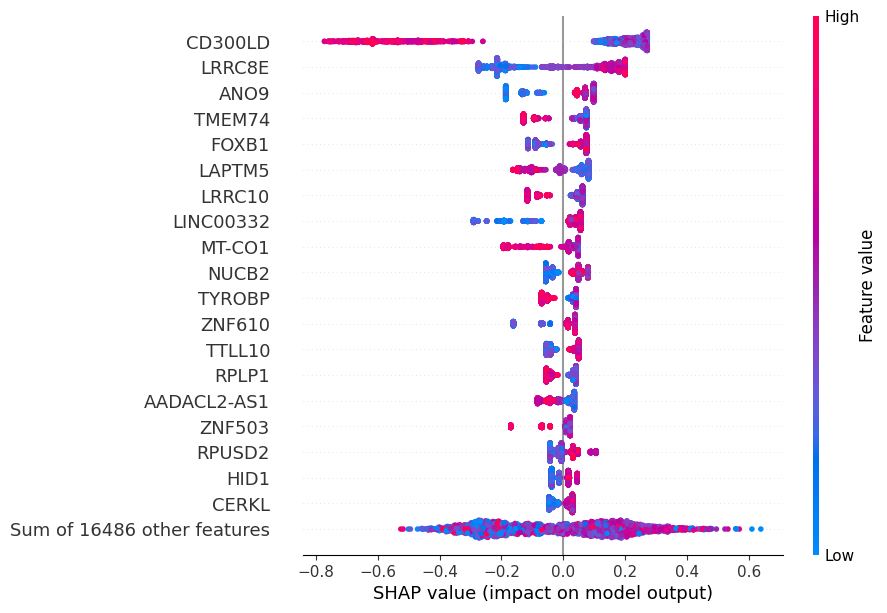

In [12]:
plt.close()
fig, ax = plt.subplots()
shap.plots.beeswarm(shap_object, max_display=20, plot_size=(10, 7), show=False)
fig.subplots_adjust(left=0.3)

Text(0.5, 1.0, 'Top 25 features for importance')

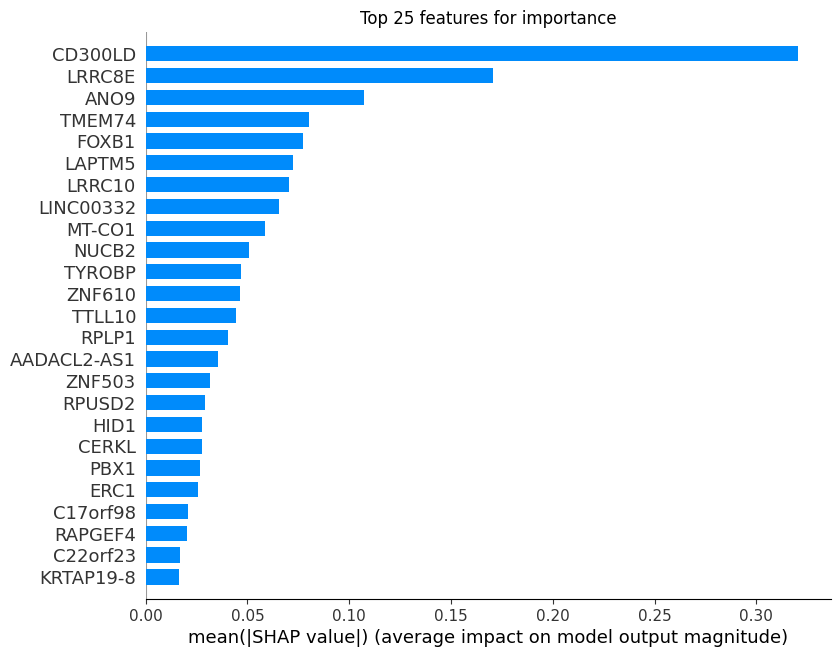

In [13]:
plt.close()
fig, ax = plt.subplots()
shap.summary_plot(shap_object, current_Scaled, max_display=25, plot_type="bar", show=False, plot_size=(10, 7))
fig.subplots_adjust(left=0.3, top=0.9)
plt.title('Top 25 features for importance')

In [14]:
cont = 0
for value in expl_sorted.values():
      if value != 0:
        cont+=1

print('Feature con importanza non zero:', cont)

Feature con importanza non zero: 64


<h3>Distribution of feature importances</h3>

Mean: 0.028186062177052572
Stadnard Deviation: 0.047293636514354885
Number of features of 0 sigma: 17 ['CD300LD', 'LRRC8E', 'ANO9', 'TMEM74', 'FOXB1', 'LAPTM5', 'LRRC10', 'LINC00332', 'MT-CO1', 'NUCB2', 'TYROBP', 'ZNF610', 'TTLL10', 'RPLP1', 'AADACL2-AS1', 'ZNF503', 'RPUSD2']


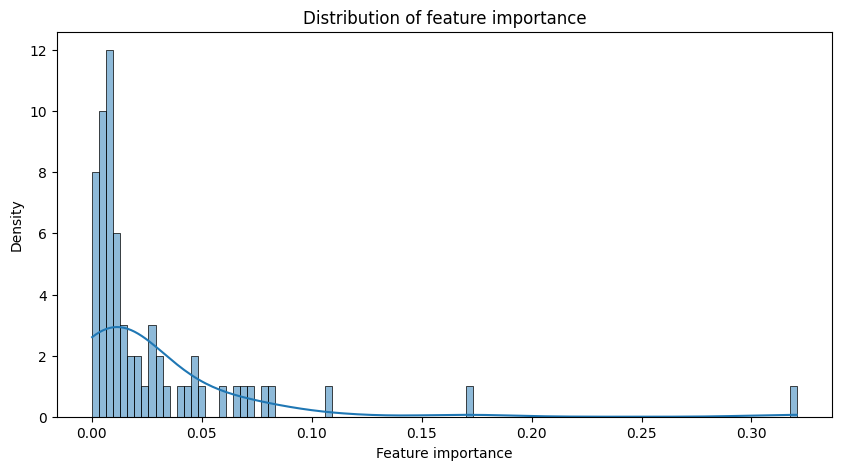

In [15]:
non_zeroShap = [value for value in expl_sorted.values() if value != 0]
mean = np.mean(non_zeroShap)
std = np.std(non_zeroShap)

print('Mean:', mean)
print('Stadnard Deviation:', std)
k=0
bestFeatures = [key for key, value in expl_sorted.items() if value > (k*std)+mean]
print(f"Number of features of {k} sigma:", len(bestFeatures), bestFeatures)

plt.close()
plt.figure(figsize=(10,5))
sns.histplot(data=non_zeroShap, bins=100, kde=True)
plt.title('Distribution of feature importance')
plt.xlabel('Feature importance')
plt.ylabel('Density')
plt.show()

<h3>Cumulative Importance</h3>

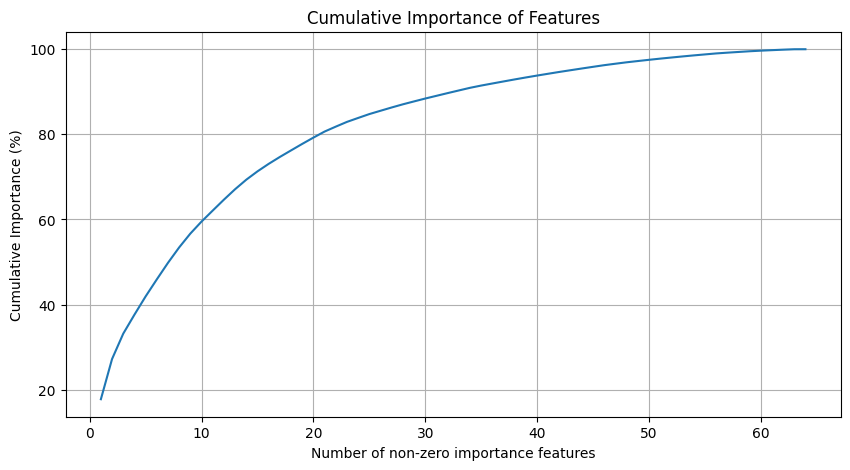

In [16]:
cumulativeImportance = (np.array(list(feature_nonZero.values())).cumsum() / np.array(list(feature_nonZero.values())).sum()) * 100

plt.close()
plt.figure(figsize=(10,5))
plt.plot(range(1, len(cumulativeImportance)+1), cumulativeImportance)
plt.xlabel('Number of non-zero importance features')
plt.ylabel('Cumulative Importance (%)')
plt.title('Cumulative Importance of Features')
plt.grid()
plt.show()

In [17]:
print(list(feature_nonZero.keys())[:300])

['CD300LD', 'LRRC8E', 'ANO9', 'TMEM74', 'FOXB1', 'LAPTM5', 'LRRC10', 'LINC00332', 'MT-CO1', 'NUCB2', 'TYROBP', 'ZNF610', 'TTLL10', 'RPLP1', 'AADACL2-AS1', 'ZNF503', 'RPUSD2', 'HID1', 'CERKL', 'PBX1', 'ERC1', 'C17orf98', 'RAPGEF4', 'C22orf23', 'KRTAP19-8', 'TOX', 'PNCK', 'TIGIT', 'PTK6', 'TSPAN13', 'IGHV4-28', 'COL5A3', 'MPZL2', 'MIA2', 'OVOL1', 'KCTD15', 'KRT75', 'RTP5', 'FCGR2A', 'IGHM', 'ARHGEF35', 'ROBO1', 'ADORA2A', 'CLNK', 'PPFIA3', 'KIF5A', 'EPHX2', 'MFAP1', 'HAPLN3', 'CCL17', 'NENF', 'ZNF670', 'PPP1R14B', 'BCL2A1', 'PDE6H', 'GOLGA8B', 'ACMSD', 'LINC00526', 'NME2', 'PTOV1-AS1', 'UTS2', 'IGKV1-9', 'NCR3', 'B3GALT1']


<h3>Bar plot of importances over the two classes</h3>

In [18]:
current = dataset_x

current["Label"] = dataset.obs["condition"].values


cohorts = ["MS" if label == "MS" else "CTRL" for label in current['Label']]
cohort_explanation = shap_object.cohorts(cohorts)
cohort_means = cohort_explanation.abs.mean(0)

cohort_df = pd.DataFrame({
    'MS': cohort_explanation.cohorts['MS'].values.mean(0),
    'CTRL': cohort_explanation.cohorts['CTRL'].values.mean(0)
}, index=dataset.var_names) 

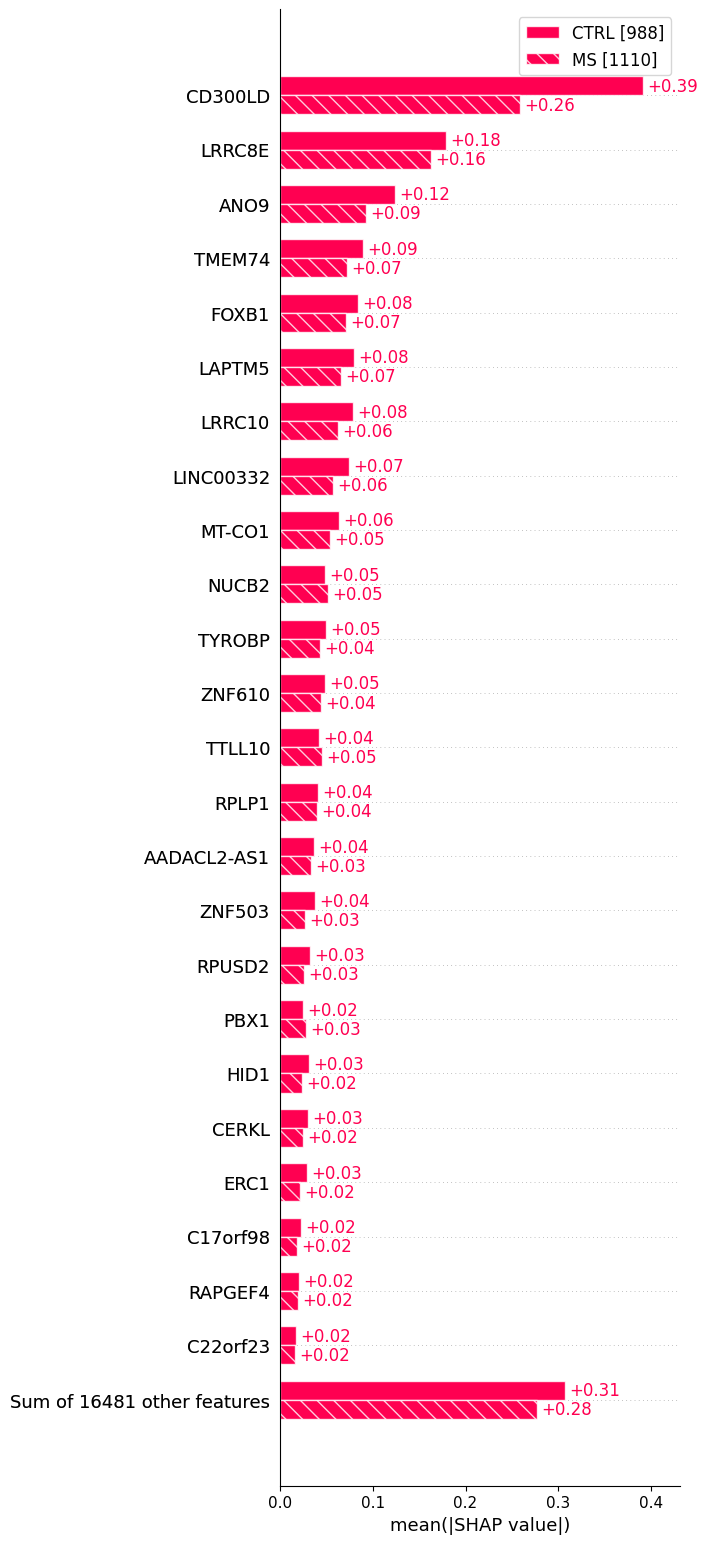

In [19]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 5))
shap.plots.bar(cohort_means, max_display=25, show=False)
fig.subplots_adjust(left=0.4)

Showing the genes where the importance for the class MS is higher than a value epsilon compared to the importance of the Control class

In [20]:
diff = np.abs(cohort_df['MS'] - cohort_df['CTRL'])

Difference importance between classes distribution

In [21]:
diff_mean = np.mean(diff)
diff_meadian = np.median(diff)
diff_std = np.std(diff)

print('Mean:', diff_mean)
print('Median:', diff_meadian)
print('Stadnard Deviation:', diff_std)
k=0
bestFeatures = [key for key, value in expl_sorted.items() if value > (k*diff_std)+diff_mean]
print(f"Number of features over {k} sigma:", len(bestFeatures), bestFeatures)

Mean: 0.00010907768579214779
Median: 0.0
Stadnard Deviation: 0.003915983462035952
Number of features over 0 sigma: 64 ['CD300LD', 'LRRC8E', 'ANO9', 'TMEM74', 'FOXB1', 'LAPTM5', 'LRRC10', 'LINC00332', 'MT-CO1', 'NUCB2', 'TYROBP', 'ZNF610', 'TTLL10', 'RPLP1', 'AADACL2-AS1', 'ZNF503', 'RPUSD2', 'HID1', 'CERKL', 'PBX1', 'ERC1', 'C17orf98', 'RAPGEF4', 'C22orf23', 'KRTAP19-8', 'TOX', 'PNCK', 'TIGIT', 'PTK6', 'TSPAN13', 'IGHV4-28', 'COL5A3', 'MPZL2', 'MIA2', 'OVOL1', 'KCTD15', 'KRT75', 'RTP5', 'FCGR2A', 'IGHM', 'ARHGEF35', 'ROBO1', 'ADORA2A', 'CLNK', 'PPFIA3', 'KIF5A', 'EPHX2', 'MFAP1', 'HAPLN3', 'CCL17', 'NENF', 'ZNF670', 'PPP1R14B', 'BCL2A1', 'PDE6H', 'GOLGA8B', 'ACMSD', 'LINC00526', 'NME2', 'PTOV1-AS1', 'UTS2', 'IGKV1-9', 'NCR3', 'B3GALT1']


Test for difference of importance between classes

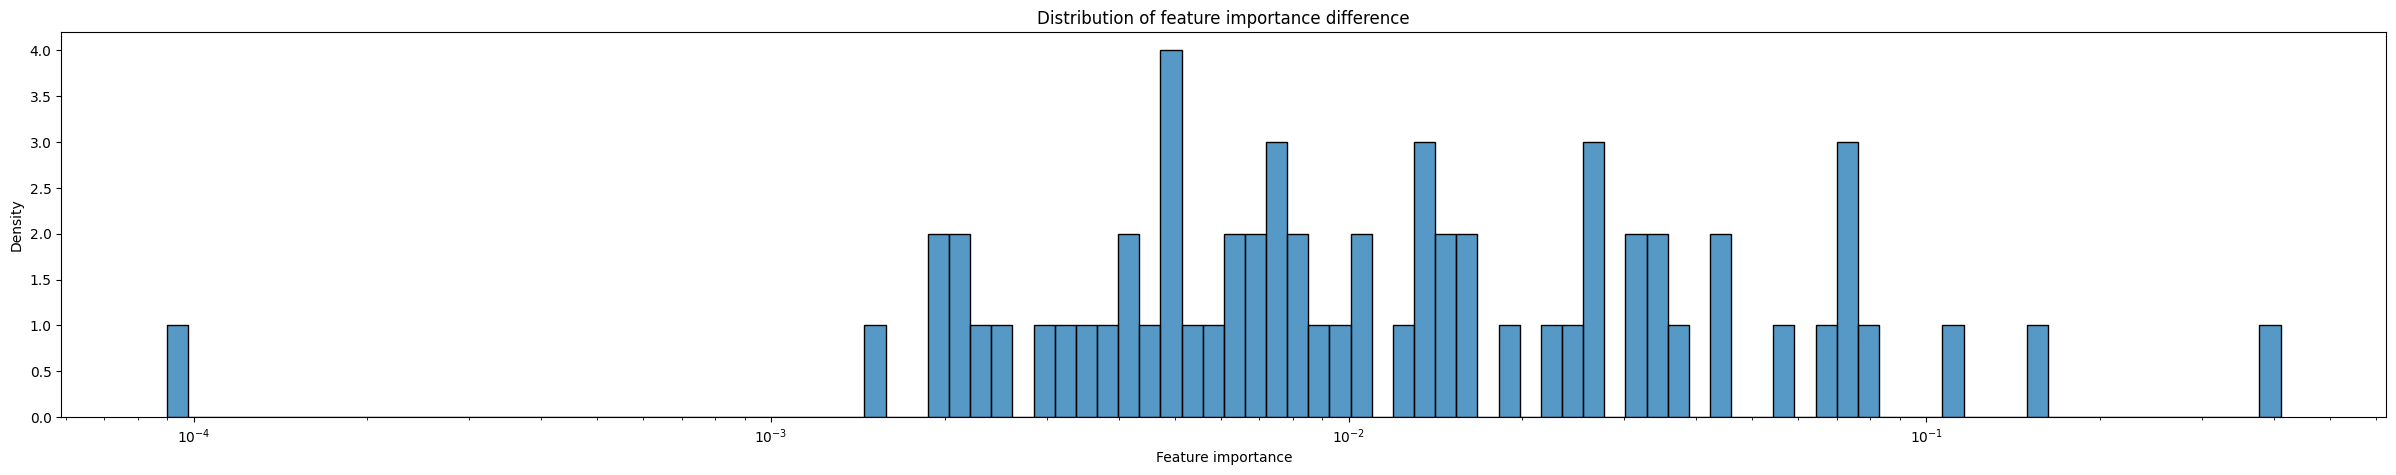

In [22]:
plt.close()
plt.figure(figsize=(30,5))
sns.histplot(data=diff, bins=100, log_scale=True)
plt.title('Distribution of feature importance difference')
plt.xlabel('Feature importance')
plt.ylabel('Density')
plt.show()

In [23]:
epsilon = 0.01  # Modifica questo valore
significant_features = diff[diff >= epsilon].index.tolist()

print(f"Feature con differenza >= {epsilon}:")
print(len(significant_features), significant_features)

Feature con differenza >= 0.01:
32 ['TTLL10', 'LAPTM5', 'PBX1', 'RAPGEF4', 'CERKL', 'TIGIT', 'AADACL2-AS1', 'PNCK', 'TOX', 'TMEM74', 'ANO9', 'NUCB2', 'MPZL2', 'LRRC10', 'LINC00332', 'IGHV4-28', 'RPUSD2', 'FOXB1', 'C17orf98', 'CD300LD', 'HID1', 'PTK6', 'LRRC8E', 'KCTD15', 'ZNF610', 'C22orf23', 'KRTAP19-8', 'TYROBP', 'ERC1', 'MT-CO1', 'ZNF503', 'RPLP1']


DEA between cohorts over SHAP values

In [24]:
warnings.filterwarnings("ignore")

current = dataset_x
current["Label"] = dataset.obs["condition"].values


cohorts = ["MS" if label == "MS" else "Control" for label in current['Label']]
cohort_explanation = shap_object.cohorts(cohorts)

cohort_ms = pd.DataFrame(cohort_explanation.cohorts['MS'].values, columns=dataset.var_names)
cohort_control = pd.DataFrame(cohort_explanation.cohorts['Control'].values, columns=dataset.var_names)

p_values = [mannwhitneyu(cohort_control[gene], cohort_ms[gene])[1] for gene in cohort_control.columns]
boolean, p_values_corrected = fdrcorrection(p_values, alpha=0.05)
deGenes = {gene:value for gene, sig, value in zip(cohort_control.columns, boolean, p_values_corrected) if sig}

print(len(deGenes), list(deGenes.keys()))

63 ['TTLL10', 'UTS2', 'LAPTM5', 'PBX1', 'NENF', 'ZNF670', 'IGKV1-9', 'ACMSD', 'RAPGEF4', 'CERKL', 'RTP5', 'ROBO1', 'TIGIT', 'AADACL2-AS1', 'CLNK', 'NCR3', 'ARHGEF35', 'PNCK', 'EPHX2', 'TOX', 'TMEM74', 'ANO9', 'NUCB2', 'PPP1R14B', 'OVOL1', 'MPZL2', 'PDE6H', 'KRT75', 'KIF5A', 'LRRC10', 'LINC00332', 'MIA2', 'IGHV4-28', 'RPUSD2', 'MFAP1', 'FOXB1', 'BCL2A1', 'HAPLN3', 'CCL17', 'C17orf98', 'NME2', 'CD300LD', 'HID1', 'LINC00526', 'PTK6', 'LRRC8E', 'COL5A3', 'KCTD15', 'PPFIA3', 'PTOV1-AS1', 'ZNF610', 'ADORA2A', 'C22orf23', 'KRTAP19-8', 'TYROBP', 'ERC1', 'FCGR2A', 'GOLGA8B', 'MT-CO1', 'ZNF503', 'TSPAN13', 'RPLP1', 'IGHM']


In [25]:
print(len(set(significant_features).intersection(set(deGenes.keys()))), set(significant_features).intersection(set(deGenes.keys())))

32 {'AADACL2-AS1', 'MT-CO1', 'LRRC10', 'LINC00332', 'KCTD15', 'CD300LD', 'ANO9', 'TIGIT', 'RPUSD2', 'TYROBP', 'TTLL10', 'MPZL2', 'ERC1', 'PTK6', 'LRRC8E', 'ZNF610', 'HID1', 'KRTAP19-8', 'LAPTM5', 'FOXB1', 'PNCK', 'TMEM74', 'RAPGEF4', 'ZNF503', 'CERKL', 'TOX', 'PBX1', 'IGHV4-28', 'C17orf98', 'C22orf23', 'RPLP1', 'NUCB2'}


<h3>Dependence plot with interactions for the 2 known gene of the family HLA</h3>

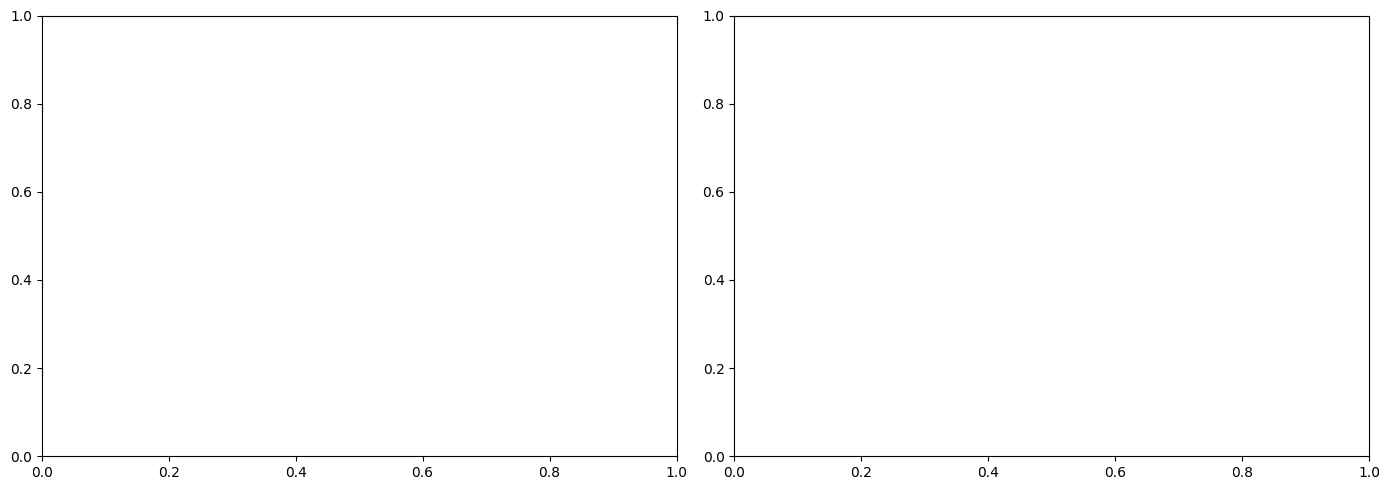

In [26]:
shap_values = shap_object.values

plt.close()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
#shap.dependence_plot("HLA-DRB1", shap_values, current_Scaled, show=False, interaction_index='HLA-DRB5', ax=ax[0])
#shap.dependence_plot("HLA-DRB5", shap_values, current_Scaled, show=False, interaction_index='HLA-DRB1', ax=ax[1])
plt.tight_layout()

<h3>Dependence plot of the first 20 features for importance</h3>

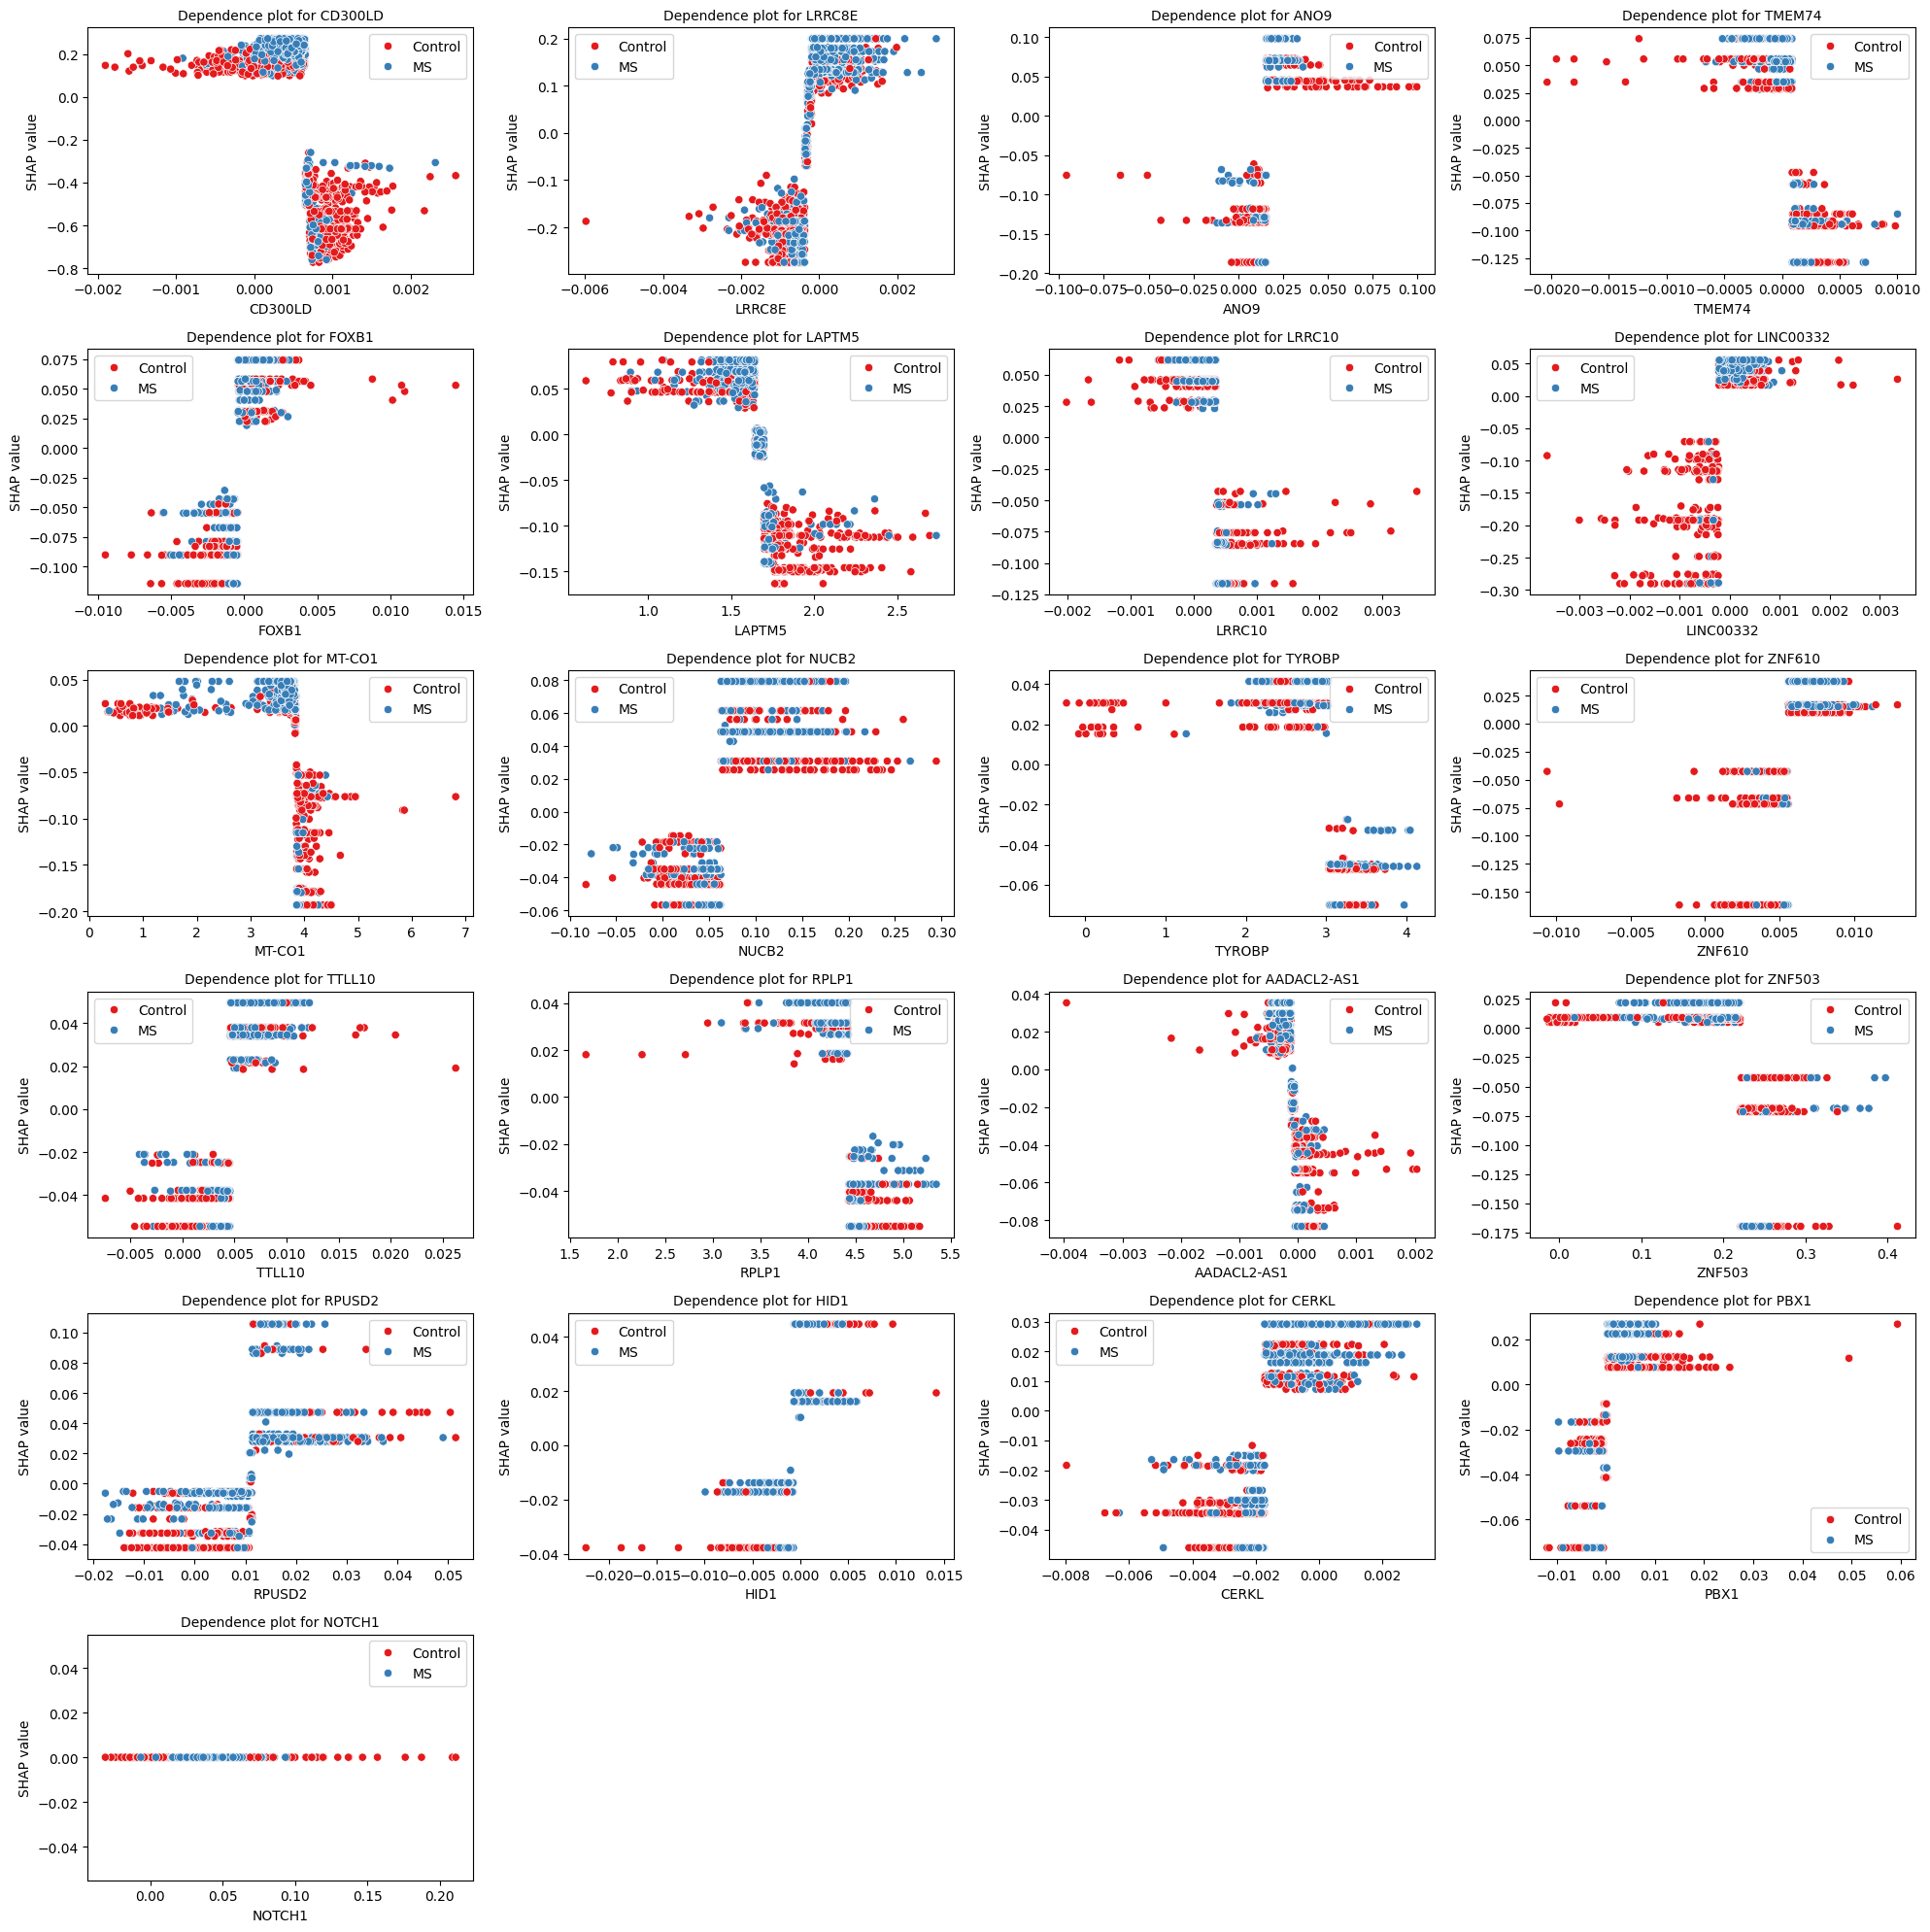

In [27]:
plt.close()

warnings.filterwarnings("ignore")

current = dataset_x

n = 6
fig, axes = plt.subplots(n, 4, figsize=(20, 20))
axes = axes.flatten() 

featureList = list(expl_sorted.keys())[:20]
featureList.append('NOTCH1')

for i, feature in enumerate(featureList):
    if i >= len(axes):
        break
    
    shap_vals = shap_object.values[:, current.columns.get_loc(feature)]
    feature_vals = current[feature].values

    customDf = pd.DataFrame({
        'SHAP': shap_vals,
        'Feature': feature_vals,
        'Label': ['MS' if value == "MS" else 'Control' for value in label]

    })

    sns.scatterplot(data=customDf, x='Feature', y='SHAP', hue='Label', palette='Set1', ax=axes[i])
    
    axes[i].set_title(f'Dependence plot for {feature}', fontsize=10)
    axes[i].set_xlabel(f'{feature}')
    axes[i].set_ylabel('SHAP value')
    axes[i].legend()

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<h3>Dependence plot with interactions beetween the combination of the first 5 features for importance</h3>

ValueError: Could not find feature named: SLC30A4

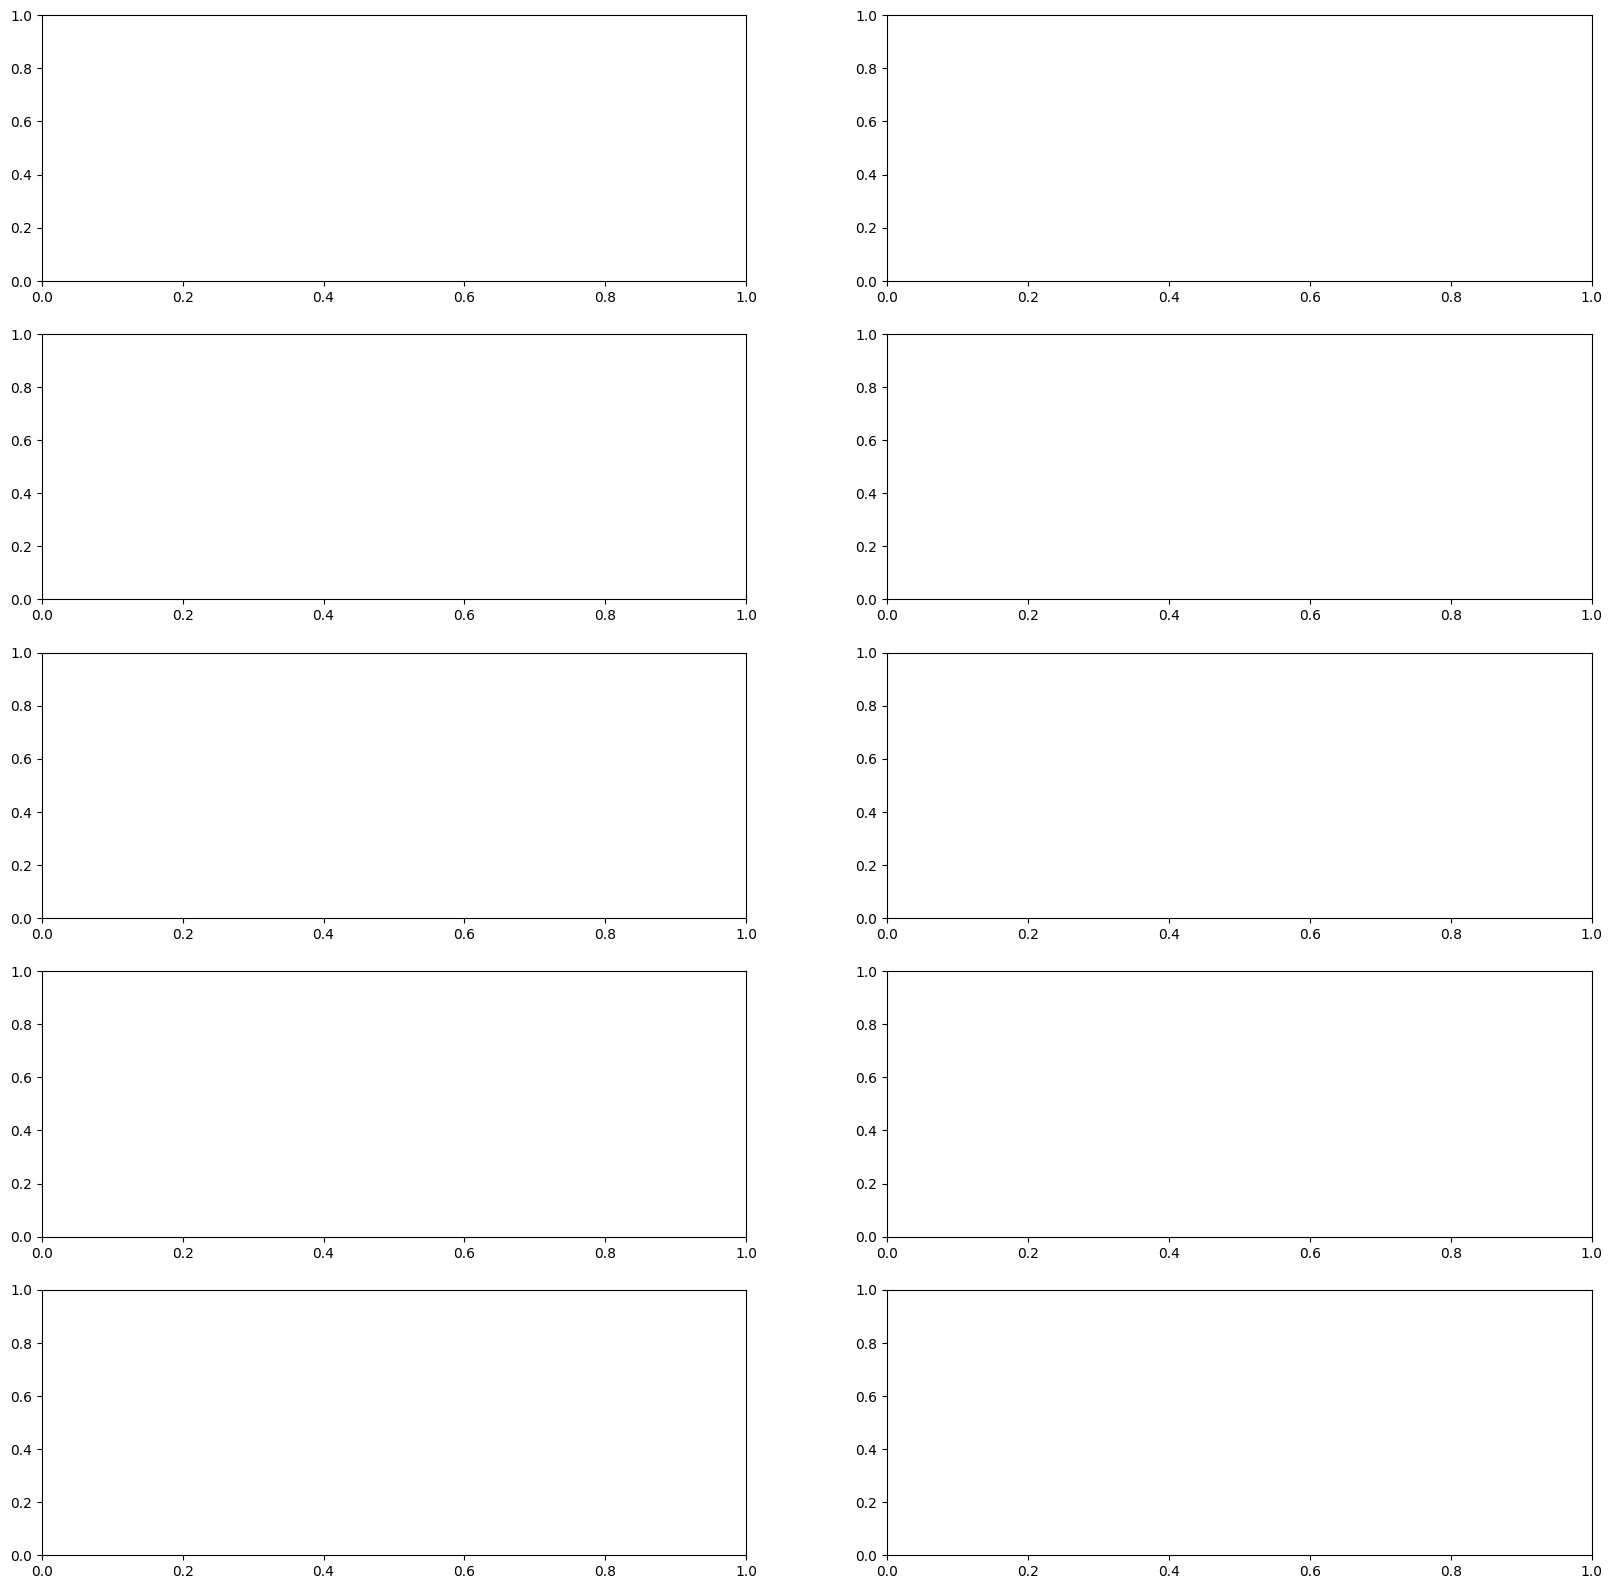

In [30]:
plt.close()

n = 5
fig, axes = plt.subplots(n, 2, figsize=(20, 20))
axes = axes.flatten()

features = list(expl_sorted.keys())[:5]
featuresCoupled = list(combinations(features, 2))

for i, feature in enumerate(featuresCoupled):
    if i >= len(axes): 
        break
    shap.dependence_plot(
        feature[0],
        shap_values,
        current_Scaled, 
        interaction_index=feature[1],
        ax=axes[i],
        alpha=1,
        show=False
    )
    
    axes[i].set_title(f'Dependence plot for {feature}', fontsize=10)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()

<h3>Shap correlation between top genes</h3>

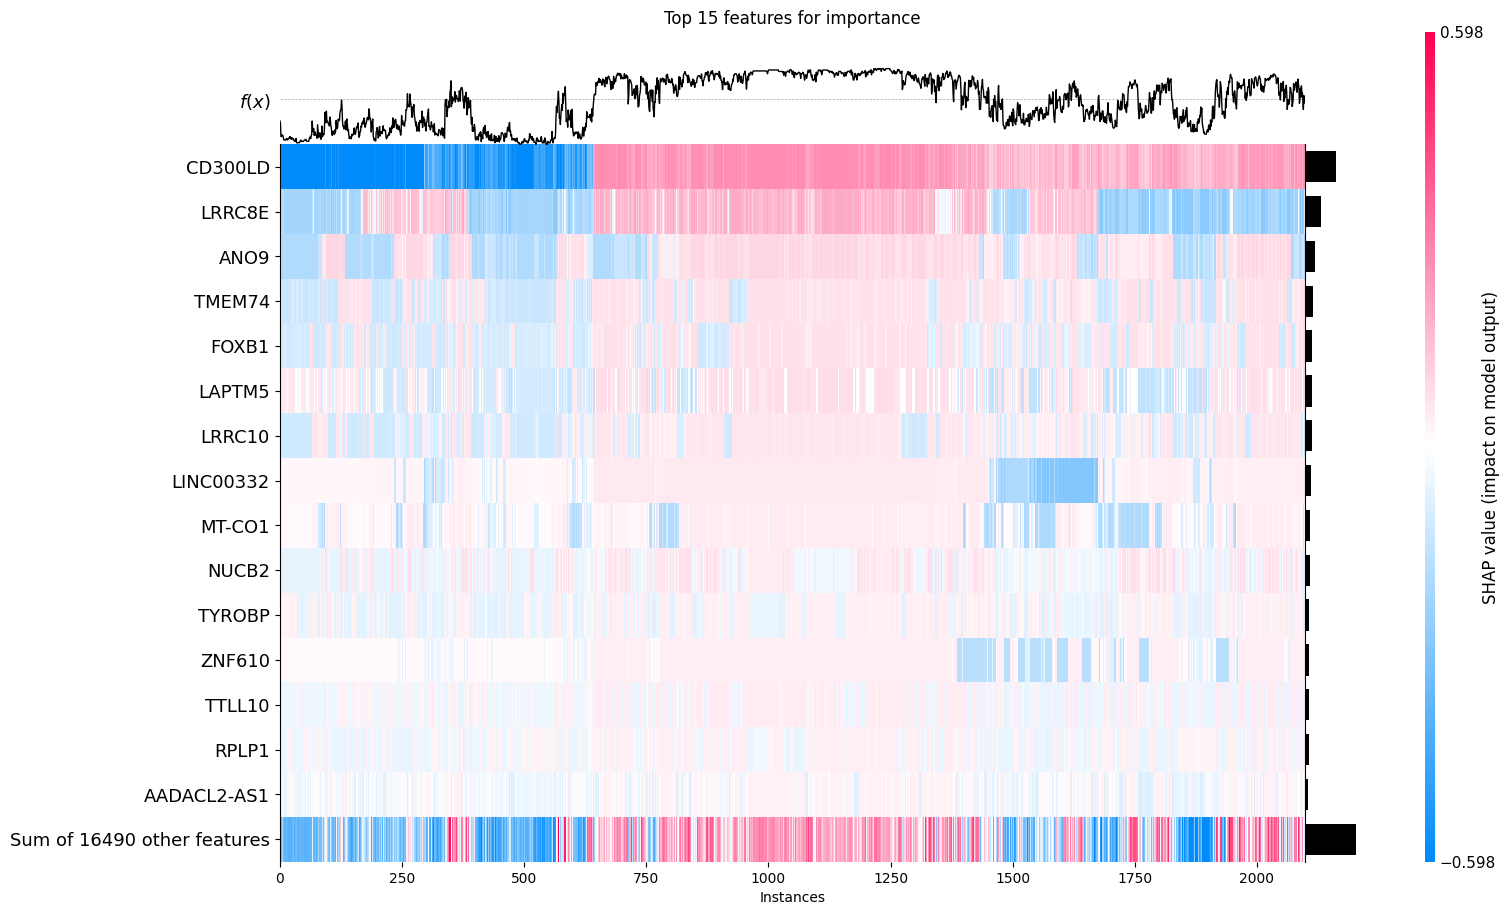

In [28]:
plt.close()
fig, ax = plt.subplots()
shap.plots.heatmap(shap_object, max_display=16, show=False, plot_width=20)
fig.subplots_adjust(left=0.3, top=0.9)
plt.title('Top 15 features for importance')
plt.show()

In [35]:
shapCorr = pd.DataFrame(shap_object.values, columns=dataset.var_names)[list(expl_sorted.keys())].corr()

plt.figure(figsize=(15,10))
sns.heatmap(shapCorr, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matrice di Correlazione')
plt.show()

KeyboardInterrupt: 

<h3>Insert ex clusters</h3>

In [29]:
clusters = joblib.load("uniqueClusters.pkl")
clusters

{('TAS1R3', 'SOX5'): 'TAS1R3',
 ('UBE4B', 'DBT'): 'DBT',
 ('PRDM2', 'ZBTB20'): 'PRDM2',
 ('EIF4G3', 'UBE2Q1'): 'UBE2Q1',
 ('CDC42', 'CAPZA1'): 'CAPZA1',
 ('NCMAP', 'TMEM107'): 'NCMAP',
 ('PIGV', 'STYXL1'): 'PIGV',
 ('XKR8', 'NXT1'): 'XKR8',
 ('MAP7D1', 'ELAVL1'): 'ELAVL1',
 ('LINC00853', 'GAPLINC'): 'LINC00853',
 ('IFI44', 'RMND1'): 'RMND1',
 ('HIST2H2BE', 'TMEM144'): 'TMEM144',
 ('S100A13', 'NUPR1'): 'S100A13',
 ('NUP210L', 'MTRNR2L1'): 'NUP210L',
 ('LMNA', 'EMP1'): 'EMP1',
 ('CD1D', 'GAPT'): 'CD1D',
 ('SLAMF8', 'TATDN1'): 'SLAMF8',
 ('ALDH9A1', 'PLIN2'): 'PLIN2',
 ('POGK', 'AKAP1'): 'AKAP1',
 ('ADCY10', 'SORCS1'): 'SORCS1',
 ('CCDC181', 'CYP39A1'): 'CCDC181',
 ('TOR1AIP1', 'JKAMP'): 'JKAMP',
 ('SERTAD4-AS1', 'PHOX2A'): 'PHOX2A',
 ('ATP6V1E2', 'TRIM66'): 'TRIM66',
 ('DOK1', 'ORAI3'): 'DOK1',
 ('MIR4435-2HG', 'CDCA7'): 'CDCA7',
 ('TANC1', 'WWC2-AS2'): 'WWC2-AS2',
 ('DPP4', 'SOCS2'): 'SOCS2',
 ('DHRS9', 'IGSF6'): 'DHRS9',
 ('DNAJC10', 'RAB11FIP1'): 'DNAJC10',
 ('IDH1', 'ZWILCH'): 'ZWILC

In [7]:
clusterEnriched = addGeneClusters(expl_sorted)
feature_nonZeroEnriched = addGeneClusters(feature_nonZero)

TAS1R3 True
TAS1R3 0.0 ['SOX5'] [0.0]
DBT True
DBT 0.0 ['UBE4B'] [0.0]
PRDM2 True
PRDM2 0.0 ['ZBTB20'] [0.0]
UBE2Q1 True
UBE2Q1 0.0 ['EIF4G3'] [0.0]
CAPZA1 True
CAPZA1 0.0 ['CDC42'] [0.0]
NCMAP True
NCMAP 0.0 ['TMEM107'] [0.0]
PIGV True
PIGV 0.0 ['STYXL1'] [0.0]
XKR8 True
XKR8 0.0 ['NXT1'] [0.0]
ELAVL1 True
ELAVL1 0.0 ['MAP7D1'] [0.0]
LINC00853 True
LINC00853 0.0 ['GAPLINC'] [0.0]
RMND1 True
RMND1 0.0 ['IFI44'] [0.0]
TMEM144 True
TMEM144 0.0 ['HIST2H2BE'] [0.0]
S100A13 True
S100A13 0.0 ['NUPR1'] [0.0]
NUP210L True
NUP210L 0.0 ['MTRNR2L1'] [0.0]
EMP1 True
EMP1 0.0 ['LMNA'] [0.0]
CD1D True
CD1D 0.0 ['GAPT'] [0.0]
SLAMF8 True
SLAMF8 0.0 ['TATDN1'] [0.0]
PLIN2 True
PLIN2 0.0 ['ALDH9A1'] [0.0]
AKAP1 True
AKAP1 0.0 ['POGK'] [0.0]
SORCS1 True
SORCS1 0.0 ['ADCY10'] [0.0]
CCDC181 True
CCDC181 0.0 ['CYP39A1'] [0.0]
JKAMP True
JKAMP 0.0 ['TOR1AIP1'] [0.0]
PHOX2A True
PHOX2A 0.0 ['SERTAD4-AS1'] [0.0]
TRIM66 True
TRIM66 0.0 ['ATP6V1E2'] [0.0]
DOK1 True
DOK1 0.0 ['ORAI3'] [0.0]
CDCA7 True
CDCA7 0.0 

CCDC82 0.0 ['TAF7', 'POLR3D', 'TINF2'] [0.0, 0.0, 0.0]
EVL True
EVL 0.0 ['CLDND1', 'LEPROTL1', 'IMP3'] [0.0, 0.0, 0.0]
ZNF703 True
ZNF703 0.0 ['MITF', 'ARL13B', 'RASSF8-AS1'] [0.0, 0.0, 0.0]
PTPN22 True
PTPN22 0.0 ['ARMC1', 'ATG13', 'SLC35C2'] [0.0, 0.0, 0.0]
ADAM19 True
ADAM19 0.0 ['BTLA', 'TPD52', 'CD82'] [0.0, 0.0, 0.0]
USB1 True
USB1 0.0 ['DECR1', 'RAB11A', 'SIRT6'] [0.0, 0.0, 0.0]
PABPC1 True
PABPC1 0.0 ['NAP1L1', 'RSL1D1', 'EEF2'] [0.0, 0.0, 0.0]
TAOK3 True
TAOK3 0.0 ['RCC2', 'RPS6KA3', 'ASAP1'] [0.0, 0.0, 0.0]
DGAT1 True
DGAT1 0.0 ['LPGAT1', 'IQGAP1', 'SLC38A10'] [0.0, 0.0, 0.0]
KRR1 True
KRR1 0.0 ['PUM3', 'ZC3H13', 'MLLT6'] [0.0, 0.0, 0.0]
MLLT3 True
MLLT3 0.0 ['TCF7', 'ITK', 'BCL11B'] [0.0, 0.0, 0.0]
BAG1 True
BAG1 0.0 ['RGS12', 'SFXN3', 'CRK'] [0.0, 0.0, 0.0]
AQP3 True
AQP3 0.0 ['CISH', 'FLT3LG', 'NOSIP'] [0.0, 0.0, 0.0]
TRIM14 True
TRIM14 0.0 ['ALS2CL', 'MAP7', 'LINC00891'] [0.0, 0.0, 0.0]
CD55 True
CD55 0.0 ['KLF4', 'SLC43A2', 'MAPK7'] [0.0, 0.0, 0.0]
FAM225A True
FAM225A 0

NSMCE1 0.0 ['LINC01184', 'THYN1', 'MRPL43', 'EID1', 'LCMT1'] [0.0, 0.0, 0.0, 0.0, 0.0]
PDCD4 True
PDCD4 0.0 ['MTERF4', 'CYFIP2', 'FAM107B', 'TNRC6C', 'TMC8'] [0.0, 0.0, 0.0, 0.0, 0.0]
IFI44L True
IFI44L 0.0 ['CXCL3', 'CXCL2', 'RNF150', 'CXCL12', 'CCL8'] [0.0, 0.0, 0.0, 0.0, 0.0]
IL17RC True
IL17RC 0.0 ['PTAFR', 'FRMD4B', 'CPED1', 'CNTLN', 'RASSF4'] [0.0, 0.0, 0.0, 0.0, 0.0]
EGR1 True
EGR1 0.0 ['HLX', 'EGR3', 'EGR2', 'CCL3', 'CCL4L2'] [0.0, 0.0, 0.0, 0.0, 0.0]
REEP3 True
REEP3 0.0 ['LIMS1', 'ETF1', 'HSPA9', 'OSTM1', 'ARFGAP3'] [0.0, 0.0, 0.0, 0.0, 0.0]
CSRNP1 True
CSRNP1 0.0 ['SLC1A3', 'CH25H', 'HIF1A', 'CCL3', 'NFKBID'] [0.0, 0.0, 0.0, 0.0, 0.0]
LAMP1 True
LAMP1 0.0 ['ITGB5', 'TOR4A', 'TBC1D12', 'TIMP2', 'DNAJC5'] [0.0, 0.0, 0.0, 0.0, 0.0]
GOT1 True
GOT1 0.0 ['TCEAL3', 'KAT5', 'RASSF8-AS1', 'ARL6IP1', 'TPM4'] [0.0, 0.0, 0.0, 0.0, 0.0]
TRAF3IP3 True
TRAF3IP3 0.0 ['ITGA4', 'ANKZF1', 'TBC1D10C', 'ADD3', 'ARHGEF1'] [0.0, 0.0, 0.0, 0.0, 0.0]
HSPBAP1 True
HSPBAP1 0.0 ['ERMAP', 'DSTYK', 'HMBO

GPAT4 0.0 ['SNRNP48', 'ALG13', 'UBXN2B', 'AZIN1', 'LUC7L', 'SGTA', 'ICOSLG'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
GPAA1 True
GPAA1 0.0 ['RNF13', 'B4GALT7', 'GUSB', 'SCAMP2', 'ENTPD6', 'HM13', 'PSENEN'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
AOC1 True
AOC1 0.0 ['LAD1', 'FOXD4L1', 'LAMP3', 'FOXD4', 'CCL19', 'HNF1B', 'NCCRP1'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
GRHPR True
GRHPR 0.0 ['METTL5', 'GLRX', 'PLGRKT', 'HINT2', 'MRPL48', 'CBX1', 'PSMF1'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
PIEZO1 True
PIEZO1 0.0 ['SKI', 'CTDSP1', 'LRRFIP1', 'PDLIM5', 'KLF9', 'WDR5', 'ITGA5'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
NELFCD True
NELFCD 0.0 ['SUB1', 'DBF4', 'ARPC5L', 'RAD9A', 'UBE2N', 'RNF167', 'NUP88'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
TMEM173 True
TMEM173 0.0 ['JAGN1', 'NCK1', 'OCIAD1', 'TAZ', 'ARRDC1', 'NUBP2', 'POLR3F'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
PGD True
PGD 0.0 ['PLA2G2C', 'ARPC1B', 'COMMD9', 'STAC3', 'COX5A', 'LRRC28', 'AP2S1'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
CD58 True
CD58 0.0 ['CYTIP'

AVPI1 0.0 ['MFSD2A', 'TREM1', 'AGPAT4', 'TRBVB', 'OLR1', 'GABARAPL1', 'KCNK10', 'RFX2', 'PLAUR', 'HAS1'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
DENND3 True
DENND3 0.0 ['EPS15', 'ANKAR', 'NISCH', 'IGF2R', 'GIMAP8', 'C5', 'COL5A1', 'SPON1', 'DMXL2', 'ATRN'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ECHDC1 True
ECHDC1 0.0 ['SCP2', 'VPS28', 'DCTN3', 'POLR2G', 'PGAM1', 'COPZ1', 'ANP32A', 'PSMA4', 'SNRPB2', 'SCAND1'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
TINF2 True
TINF2 0.0 ['POLR3GL', 'GGPS1', 'GPSM3', 'UBL4A', 'SIGIRR', 'MED9', 'MLX', 'TPGS2', 'TM9SF4', 'MFNG'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
CCDC18 True
CCDC18 0.0 ['NOTCH2', 'DENND4B', 'XPO1', 'GALNT7', 'ANKRD13D', 'MYO5A', 'C15orf39', 'IQGAP1', 'ADCY7', 'SSH2'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
SHOC2 True
SHOC2 0.0 ['UHMK1', 'PAK2', 'DHX15', 'DNAJC2', 'HCFC1', 'LASP1', 'ME2', 'DAZAP1', 'BORCS8', 'UBA2'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
LAMP3 True
LAM

...

CHMP4A 0.025686500897849695 ['SSU72', 'TMEM50A', 'MAGOH', 'CNIH4', 'PCBP1', 'MOB1A', 'PSMD1', 'UBE2K', 'PAK1IP1', 'MTRF1L', 'EIF2AK1', 'CD99', 'PBDC1', 'TOR1A', 'RIC8A', 'TRAPPC4', 'ABI1', 'CERS5', 'WBP4', 'TMEM87A', 'VPS4A', 'CFDP1', 'MPDU1', 'DNAJC7', 'MLX', 'SLC35B1', 'RNFT1', 'YWHAB', 'RAB22A', 'RAD23A', 'DDX49', 'PAF1', 'IL10RB'] [0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.025686500897849695, 0.

VAMP2 True
VAMP2 0.0 ['BSDC1', 'JAK1', 'SRSF11', 'PRPF38B', 'RSBN1', 'RPRD2', 'WDR33', 'PPIG', 'ORMDL1', 'MTERF4', 'NKTR', 'CCDC66', 'BBX', 'DHX36', 'POLR2B', 'LRBA', 'FAM172A', 'ATG12', 'NSD1', 'ABT1', 'ATF6B', 'ZNF292', 'CCM2', 'KRIT1', 'ZNF394', 'NKAP', 'DDB2', 'RSF1', 'TAF1D', 'MED17', 'PCSK7', 'KMT2A', 'PYROXD1', 'PPHLN1', 'MPHOSPH8', 'MRPS31', 'ARID4A', 'EVL', 'MARK3', 'POLR2C', 'CTCF', 'NFATC3', 'SMYD4', 'CWC25', 'SRSF1', 'FAM104A', 'TMC8', 'STK4', 'SAFB2', 'ZNF430', 'LSM14A', 'IRF3'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
TSPAN13 True
TSPAN13 0.01216069396624278 ['FCRL2', 'FCRL1', 'FCRLA', 'CR2', 'MARC2', 'LYPD6B', 'COL4A3', 'OSBPL10-AS1', 'ZNF860', 'IFT57', 'DOK7', 'STAP1', 'BANK1', 'EBF1', 'N4BP3', 'HLA-DOB', 'COL19A1', 'CD24', 'CDCA7L', 'WNT16', 'BLK', 'PKH

NDUFA4L2 0.0 ['ARHGAP29', 'S100A16', 'CRABP2', 'NMNAT2', 'PLEKHA6', 'KCNK2', 'COL3A1', 'IGFBP5', 'GXYLT2', 'RBP1', 'ZIC1', 'HES1', 'UCHL1', 'KDR', 'NPNT', 'LINC00500', 'SFRP2', 'EGFLAM', 'MAP1B', 'CTXN3', 'PDLIM4', 'NME5', 'PCDHB4', 'HMGCLL1', 'PRSS35', 'MRAP2', 'LAMA4', 'RSPO3', 'SMOC2', 'TWIST1', 'HOXA7', 'INMT', 'SFRP4', 'COL1A2', 'CALD1', 'PTN', 'RARRES2', 'EGFL6', 'CLU', 'LURAP1L', 'NFIB', 'OGN', 'PTGDS', 'IGF2', 'CTTN', 'CRYAB', 'HSPB2', 'AKR1C2', 'NEBL', 'ADIRF', 'SLC6A13', 'C1S', 'MFAP5', 'MGP', 'COL2A1', 'ARHGEF25', 'CSRP2', 'EPYC', 'DCN', 'MEDAG', 'ZIC2', 'SIX1', 'CRABP1', 'VAT1L', 'FOXC2', 'SMTNL2', 'TEKT3', 'MFAP4', 'PPP1R1B', 'TMEM100', 'ID1', 'NNAT', 'BPI', 'SLPI', 'C19orf33', 'TIMP3', 'FBLN1', 'CHODL'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

TAS1R3 False
DBT False
PRDM2 False
UBE2Q1 False
CAPZA1 False
NCMAP False
PIGV False
XKR8 False
ELAVL1 False
LINC00853 False
RMND1 False
TMEM144 False
S100A13 False
NUP210L False
EMP1 False
CD1D False
SLAMF8 False
PLIN2 False
AKAP1 False
SORCS1 False
CCDC181 False
JKAMP False
PHOX2A False
TRIM66 False
DOK1 False
CDCA7 False
WWC2-AS2 False
SOCS2 False
DHRS9 False
DNAJC10 False
ZWILCH False
NHEJ1 False
SH3BP4 False
GALNT15 False
DALRD3 False
RBM15B False
FHIT False
ST3GAL6-AS1 False
ZXDC False
NAALADL2 False
HDAC9 False
KIAA0232 False
SEL1L3 False
GUF1 False
CXCL1 False
THBS1 False
FSTL5 False
TOR1B False
SKP2 False
OXCT1 False
ARNTL False
CD180 False
ASGR1 False
RALGAPA1 False
KIF20A False
LINC00243 False
PNPLA1 False
ATP6V0E2 False
PTCRA False
RRP36 False
METTL7B False
MAD2L1BP False
OTUD6B False
GNB2 False
JAZF1 False
CLDN3 False
SPINT2 False
GDF5OS False
TMEM176A False
RPGR False
LRCH1 False
HEXA False
DDRGK1 False
STARD8 False
HMGN5 False
LAMP2 False
ZIC3 False
MTMR1 False
PER1 False

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



<h3>SHAP vs DEA graph</h3>

In [13]:
import pandas as pd

# Load the CSV file into a Pandas DataFrame
dea_genes = pd.read_csv("../DEA/CSF_BCells.csv")

# Sort the DataFrame by the 'p_val_adj' column in ascending order
sorted_dea_genes_df = dea_genes.sort_values(by="p_val_adj")

# Create a dictionary of gene: importance (p_val_adj)
gene_importance = dict(
    zip(sorted_dea_genes_df["Unnamed: 0"], sorted_dea_genes_df["p_val_adj"])
)

dea_genes = gene_importance

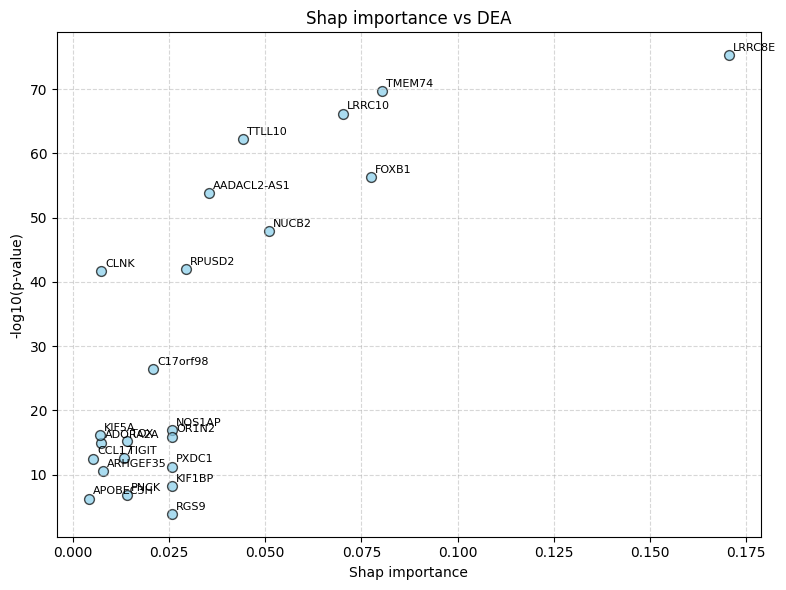

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text  # Import adjust_text

# Assuming clusterEnriched and dea_genes are already defined

point_x = []
point_y = []
labels = []
texts = [] # List to store text objects for adjust_text

for gene, value in clusterEnriched.items():
    if value > 0 and gene in dea_genes.keys():
        point_x.append(clusterEnriched[gene])
        point_y.append(-np.log10(dea_genes[gene]))
        labels.append(gene)

plt.figure(figsize=(8, 6))  # Adjusted figure size (smaller)

plt.scatter(
    point_x,
    point_y,
    color="skyblue",
    s=50,  # Reduced marker size
    edgecolors="black",
    alpha=0.7,
)

# Create annotations for each point
for i, label in enumerate(labels):
    t = plt.annotate(
        label,
        (point_x[i], point_y[i]),
        textcoords="offset points",
        xytext=(3, 3),  # Reduced offset
        ha="left",  # Align labels to the left
        fontsize=8,
        color="black",
    )
    texts.append(t)


plt.xlabel("Shap importance", fontsize=10)
plt.ylabel("-log10(p-value)", fontsize=10)
plt.title("Shap importance vs DEA", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


<h3>Venn diagram SHAP and DEA</h3>

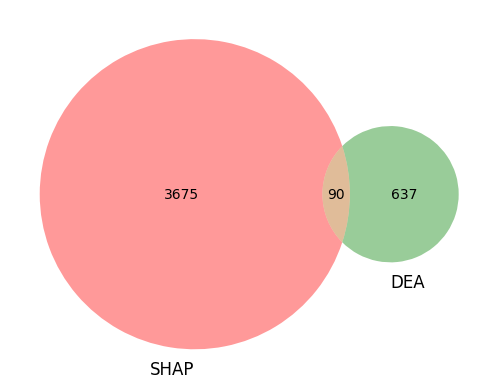

In [34]:
venn2(subsets = [set(feature_nonZeroEnriched), set(dea_genes.keys())], set_labels = ('SHAP', 'DEA'))
plt.show()

Feature important for SHAP not detected by DEA

In [35]:
print(len(set.difference(set(feature_nonZeroEnriched), set(dea_genes.keys()))), set.difference(set(feature_nonZeroEnriched), set(dea_genes.keys())))

3675 {'NR2C2', 'SALL1', 'RSPRY1', 'ATP6V0A1', 'ZFP36L1', 'LYRM2', 'ERAL1', 'TMEM179B', 'HNRNPM', 'G0S2', 'KRTCAP2', 'LIMS1', 'FLI1', 'CNTLN', 'UBR4', 'BHLHE41', 'CNR2', 'KCNJ5', 'SBNO1', 'EI24', 'CTLA4', 'STK38L', 'PTK6', 'ZBTB32', 'ARHGAP9', 'PHTF2', 'TRIM56', 'SMC4', 'NR2C1', 'ZEB1', 'TCF7', 'ZNF394', 'RANBP2', 'GGCX', 'NTMT1', 'SEMA4D', 'MPC1', 'PRPF4B', 'DNAJC2', 'TMEM134', 'RICTOR', 'MALT1', 'TNS1', 'PMS1', 'SLC25A19', 'C19orf25', 'REXO1', 'TMEM50A', 'ADAMTS12', 'MTRNR2L12', 'ARAF', 'ANXA5', 'RPLP1', 'FBXW2', 'INSIG2', 'SNX1', 'RBM25', 'BDP1', 'NDUFA4', 'MARC2', 'PHF5A', 'OGFR', 'CDK5', 'PHKB', 'SMIM7', 'MRPL21', 'KMT2E', 'DUSP3', 'FEM1A', 'PPCS', 'NUCKS1', 'CNOT4', 'PEBP1', 'DCXR', 'PITHD1', 'RPL31', 'ZNF610', 'C12orf65', 'CDC123', 'REEP3', 'FAM49B', 'UTP6', 'AC092580.4', 'SLC39A9', 'RIN2', 'HAX1', 'TTYH2', 'LSM10', 'PDE8A', 'FKBP1A', 'MRPL54', 'COQ10B', 'SRSF5', 'MED1', 'IRF1', 'NUP160', 'HSD17B10', 'COMMD5', 'POLR2G', 'DYNC1LI2', 'MVB12A', 'ATG5', 'FN3K', 'CD6', 'RPL13A', 'KLHL

Best 20 SHAP features compared with DEA

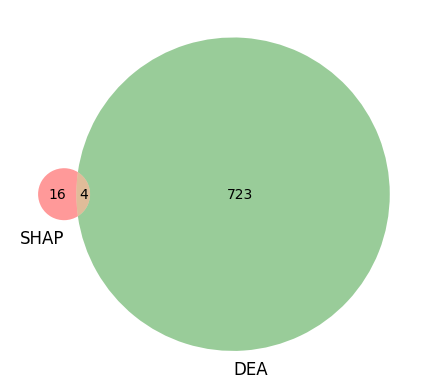

In [36]:
venn2(subsets = [set(list(feature_nonZeroEnriched.keys())[:20]), set(dea_genes.keys())], set_labels = ('SHAP', 'DEA'))
plt.show()

Known feature important for MS

In [14]:
limit = None

feature_nonZeroList = list(feature_nonZero.keys())[:limit]

for gene in ["GABPA", "CTCF", "EGR1", "YY1", "SPI1", "CLOCK", "ARNTL", "BACH1", "GFI1", "IFNB1", "MOG",  "MBP", "CD42", "IFNG", "IL17A", "IL10", "TNF", "IL1B", "IL6", "TNFRSF1A", "CYP27B1", "IL7R", "HLA-DRB1", "HLA-DRB5", "IL2RA"]:
    if gene in list(feature_nonZeroEnriched.keys())[:limit] and gene in list(dea_genes.keys())[:limit]:
        print(gene, "Both")
    elif gene in list(feature_nonZeroEnriched.keys())[:limit]:
        print(gene, "SHAP")
    elif gene in list(dea_genes.keys())[:limit]:
        print(gene, "DEA")
    else:
        print(gene, "None")

GABPA SHAP
CTCF None
EGR1 None
YY1 SHAP
SPI1 None
CLOCK SHAP
ARNTL None
BACH1 None
GFI1 DEA
IFNB1 None
MOG None
MBP SHAP
CD42 None
IFNG DEA
IL17A None
IL10 None
TNF None
IL1B None
IL6 None
TNFRSF1A SHAP
CYP27B1 None
IL7R None
HLA-DRB1 None
HLA-DRB5 None
IL2RA DEA


In [11]:
print(list(feature_nonZeroEnriched.keys()))

['CD300LD', 'LRRC8E', 'ANO9', 'TMEM74', 'FOXB1', 'LAPTM5', 'LRRC10', 'LINC00332', 'MT-CO1', 'MTRNR2L12', 'MTRNR2L8', 'MT-ND1', 'MT-ND2', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-CYB', 'NUCB2', 'TYROBP', 'FCER1G', 'NPC2', 'ZNF610', 'TTLL10', 'RPLP1', 'RPL22', 'RPL11', 'RPS8', 'RPS27A', 'RPL5', 'RPS27', 'RPS7', 'RPL31', 'EEF1B2', 'RPL37A', 'RPL32', 'RPL15', 'RPL14', 'RPL29', 'RPL24', 'RPL35A', 'RPL9', 'RPL34', 'RPS3A', 'RPL37', 'RPS23', 'RPS14', 'RPS18', 'RPL10A', 'EEF1A1', 'RPS12', 'RPS4X', 'RPL39', 'RPL10', 'RPS20', 'RPL7', 'RPL30', 'RPL8', 'RPS6', 'RPL35', 'RPL12', 'RPL7A', 'RPLP2', 'RPL27A', 'RPS13', 'FAU', 'RPS3', 'RPS25', 'RPS24', 'PFDN5', 'RPL41', 'NACA', 'RPL6', 'RPL21', 'COMMD6', 'RPS29', 'RPS17', 'RPS2', 'RPS15A', 'RPL13', 'RPL26', 'RPL23A', 'RPL19', 'RPL27', 'RPL38', 'RPS21', 'RPS15', 'RPL36', 'RPS28', 'RPL18A', 'UBA52', 'RPS16', 'RPS19', 'RPL18', 'RPL13A', 'RPS9', 'RPL28', 'RPS5', 'BTF3', 'RPL23', 'RPS10', 'RPL3', 'TOMM7', 'RPSA', 'EEF1D', '